# 05 · The DAF-MIT AIA dataset (Zenodo 12723700)

A second public record adds flights beyond the challenge set: **Flt1006** (a dedicated calibration flight), **Flt1007** (navigation), and several **2021** flights in a slightly different file layout.

Five steps: **(1)** download a few flights, **(2)** check they load, **(3)** look at the calibration flight, **(4)** see what makes a flight *navigable*, and **(5)** navigate one with the tightly-coupled filter from notebook 04.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## 1. Download a few flights
All imports are gathered here; the downloads are cached, so re-running is cheap.

In [2]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from magnavlab import data, viz
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab.ins import build_kinematics, real_ins
from magnavlab.calibration import MapBasedModifiedTL, BuiltinTL
from magnavlab.filters import Canciani38EKF
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.geomag import core_field
from magnavlab.metrics import summary

data.fetch_flight('Flt1006')   # calibration flight
data.fetch_flight('Flt1007')   # navigation flight
data.fetch_flight('Flt2005')   # 2021 flight (different file layout)
data.fetch_maps(['Eastern_395'])

  Flt1006: already present, skip
  Flt1007: already present, skip
  Flt2005: already present, skip
  maps: already present, skip


['data/maps/Eastern_395.h5']

## 2. Do the files load? (2020 and 2021 formats)
For each flight we print the sample count, rate, duration, whether the fluxgate is present and whether any required field is missing — a quick sanity check that the loader handles both file versions.

In [3]:
required = ['tt','lat','lon','alt','mag_1_c','mag_4_uc','igrf','diurnal']
for name in ['Flt1006','Flt1007','Flt2005']:
    flight = load_flight(f'data/{name}_train.h5')
    missing = [k for k in required if not flight.has(k)]
    try:
        flight.flux(); has_flux = True
    except Exception:
        has_flux = False
    print(f"{name}: {flight.n:7d} samples @ {1/flight.dt:.0f} Hz, ~{flight.n*flight.dt/60:.0f} min, "
          f"flux={has_flux}, missing={missing or 'none'}")

Flt1006:  108318 samples @ 10 Hz, ~181 min, flux=True, missing=none
Flt1007:  114506 samples @ 10 Hz, ~191 min, flux=True, missing=none
Flt2005:    6361 samples @ 10 Hz, ~11 min, flux=True, missing=none


## 3. Flt1006 — the calibration flight
A calibration flight deliberately pitches, rolls and yaws so the aircraft's magnetic field shows up from every angle — that is what makes the Tolles-Lawson coefficients *observable*. The plot shows **roll and pitch (degrees) during one calibration segment**: note the large, deliberate attitude swings, quite unlike normal survey flying.

9 calibration segments, 40986 samples total


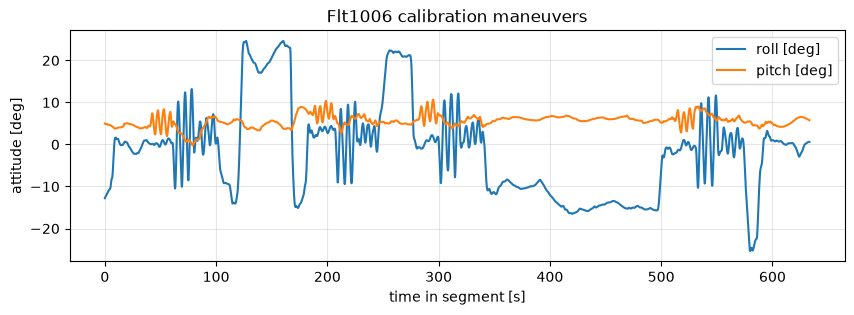

In [4]:
cal_flight = load_flight('data/Flt1006_train.h5')
segments = data.CAL_SEGMENTS['Flt1006']
total = sum(segment_indices(cal_flight, a, b).size for a, b in segments)
print(f'{len(segments)} calibration segments, {total} samples total')
a, b = segments[1]; maneuver = segment_indices(cal_flight, a, b)
time_s = cal_flight.get('tt')[maneuver] - cal_flight.get('tt')[maneuver][0]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s, cal_flight.get('roll')[maneuver], label='roll [deg]')
ax.plot(time_s, cal_flight.get('pitch')[maneuver], label='pitch [deg]')
ax.set_xlabel('time in segment [s]'); ax.set_ylabel('attitude [deg]')
ax.set_title('Flt1006 calibration maneuvers'); ax.legend(); ax.grid(alpha=0.3);

## 4. What makes a flight navigable? Altitude
A measurement is only useful if it correlates with the map. The map is drawn at 395 m; the higher you fly, the smoother and weaker the field looks, so the match degrades. Below we compare a **low** line (~400 m) with a **high** one (~800 m). Each panel overlays **black = measurement, orange = map** along that line, and the printed correlation drops as altitude rises — a concrete reminder to fly near the map's altitude.

Flt1006 Flt1006_1006.08: alt~432 m, corr(meas,map)=0.991
Flt1007 Flt1007_1007.02: alt~833 m, corr(meas,map)=0.954


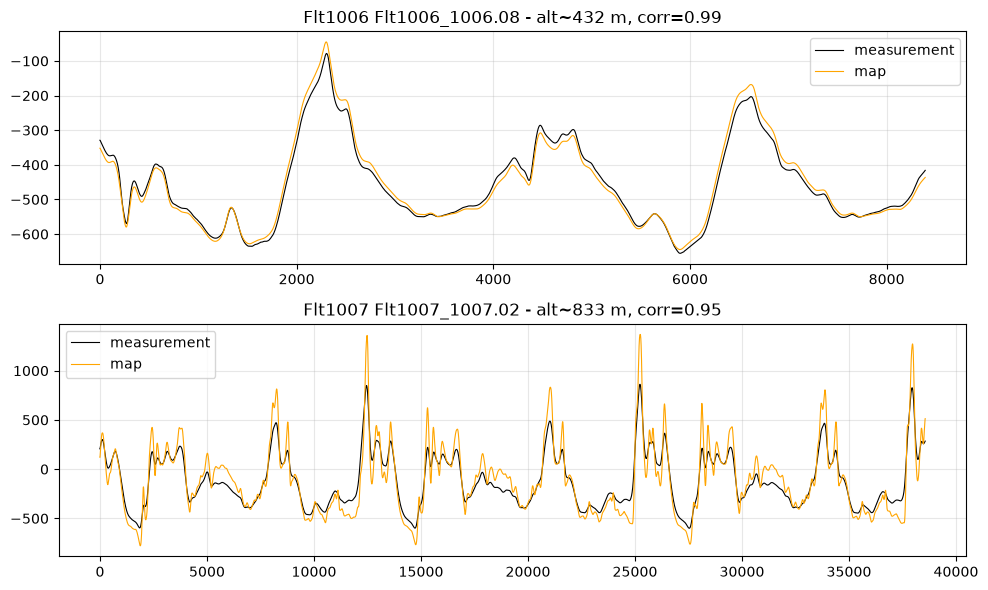

In [5]:
mag_map = load_map('data/maps/Eastern_395.h5')
def profile(name, tstart, tend):
    flight = load_flight(f'data/{name}_train.h5')
    idx = segment_indices(flight, tstart, tend)
    lat = np.radians(flight.get('lat')[idx]); lon = np.radians(flight.get('lon')[idx])
    scalar = flight.get('mag_1_c')[idx] - flight.get('diurnal')[idx]
    map_along = mag_map.value(lat, lon); valid = np.isfinite(map_along)
    scalar = scalar - np.median(scalar[valid] - map_along[valid])
    corr = np.corrcoef(scalar[valid], map_along[valid])[0, 1]
    return scalar, map_along, flight.get('alt')[idx].mean(), corr

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
for row, (name, key) in enumerate([('Flt1006','Flt1006_1006.08'), ('Flt1007','Flt1007_1007.02')]):
    window = data.NAV_WINDOWS[key]
    scalar, map_along, mean_alt, corr = profile(name, window['tstart'], window['tend'])
    print(f"{name} {key}: alt~{mean_alt:.0f} m, corr(meas,map)={corr:.3f}")
    ax[row].plot(scalar, 'k-', lw=0.8, label='measurement')
    ax[row].plot(map_along, color='orange', lw=0.8, label='map')
    ax[row].set_title(f'{name} {key} - alt~{mean_alt:.0f} m, corr={corr:.2f}')
    ax[row].legend(); ax[row].grid(alpha=0.3)
fig.tight_layout();

## 5. Navigate a flight from this dataset (tightly-coupled EKF38)
Flt1007's line 1007.06 is long and flown near the altitude of the `Renfrew_395` map, so we run the same 38-state pipeline as notebook 04 on it. This fetches the Renfrew map (~710 MB, one-off).

**5a. Load the line and build the filter inputs** (kinematics, sensors, drifting INS, batch T-L)

In [6]:
data.fetch_maps(['Renfrew_395'])                       # matched-altitude map for 1007.06
renfrew_map = load_map('data/maps/Renfrew_395.h5')
window = data.NAV_WINDOWS['Flt1007_1007.06']
flight = load_flight('data/Flt1007_train.h5')
idx = segment_indices(flight, window['tstart'], window['tend'])[::5]; dt = flight.dt * 5; n = idx.size
lat = np.radians(flight.get('lat')[idx]); lon = np.radians(flight.get('lon')[idx])
alt = flight.get('alt')[idx]
ins = real_ins(flight, idx, anchor=(lat[0], lon[0]))          # real onboard INS, anchored at start
kinematics = build_kinematics(ins['lat'], ins['lon'], ins['alt'], dt, ins['roll'], ins['pitch'])
flux = flight.flux(idx); scalar = flight.get('mag_4_uc')[idx].astype(float) - flight.get('diurnal')[idx]
core = core_field(ins['lat'], ins['lon'], ins['alt'])
cos_x, cos_y, cos_z = flux.x/scalar, flux.y/scalar, flux.z/scalar
cos_dot = (np.gradient(cos_x, dt), np.gradient(cos_y, dt), np.gradient(cos_z, dt))
half = n // 2; earth_field = renfrew_map.value(lat[:half], lon[:half]) + core[:half]
tl_batch = MapBasedModifiedTL().fit(flight.flux(idx[:half]), scalar[:half], dt, target=earth_field)

  maps: already present, skip


**5b. Run loosely- vs tightly-coupled and compare DRMS**

In [7]:
problem = NavProblem(dt=dt, map=renfrew_map, lat=ins['lat'], lon=ins['lon'], alt=ins['alt'],
                     vN=ins['vN'], vE=ins['vE'], vD=ins['vD'], meas=scalar, core=core,
                     flux=flux, cos_dot=cos_dot, fn=kinematics['fn'], fe=kinematics['fe'],
                     fd=kinematics['fd'], Cnb=kinematics['Cnb'], tl0=tl_batch.coef, P_tl0=tl_batch.P_cov)
loose = Canciani38EKF(mode='loosely').run(problem)
tight = Canciani38EKF(mode='tightly').run(problem)
for name, result in [('INS', NavResult(ins['lat'], ins['lon'])), ('loosely', loose), ('tightly', tight)]:
    print(f"{name:9s} DRMS={summary(result, lat, lon)['drms']:8.1f} m")

INS       DRMS=   298.6 m
loosely   DRMS=   137.6 m
tightly   DRMS=    67.1 m


**5c. Estimated position vs truth, on the Renfrew map**
**Black = truth**, with the loosely- and tightly-coupled estimates over the anomaly field. This flight, unique to record 12723700, navigates just like the challenge flights in notebook 04.

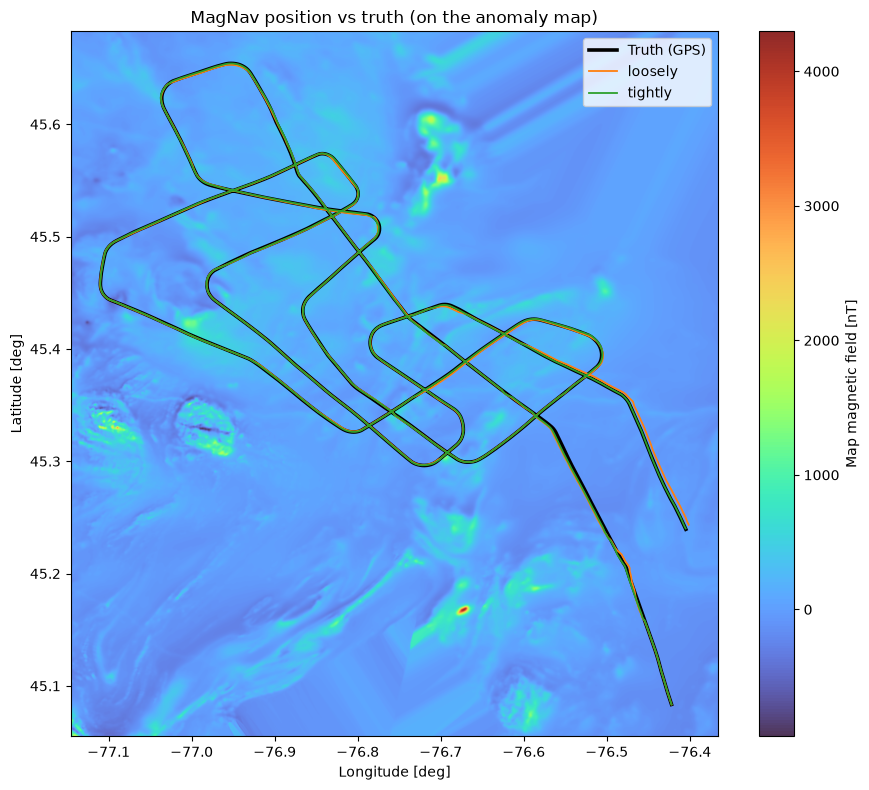

In [8]:
viz.plot_tracks_vs_truth(renfrew_map, lat, lon, {'loosely': (loose,'tab:orange'), 'tightly': (tight,'tab:green')});